## Sobolev neural network in 2D

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import SobolevTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put, PutProductMultipleAssets

from binomial_tree.binomial_tree import BinomialTree


In [2]:
exercise_type = 'american'

In [3]:
n_assets = 2

S0 = 2.0
r = 0.1

stds = np.array([0.4, 0.5])
correlation_matrix = np.array([
    [1.0, 0.6],
    [0.6, 1.0]
])

sigma = build_covariance_matrix(stds, correlation_matrix)

K = 4.0
T = 1.0
S_min = 0.0
S_max = 3 * S0

market_params = MarketParams(n_assets=n_assets, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [4]:
input_size = n_assets + 1
hidden_sizes = [64, 128, 128, 64]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)
loss_weights = {
    'pde': 2.0,
    'J2': 1.0,
    'J3': 1.0,
    'J4': 0.25
}

Iteration 0, Loss: 23.327756881713867
Iteration 100, Loss: 0.48389142751693726
Iteration 200, Loss: 0.2018352746963501
Iteration 300, Loss: 0.40257173776626587
Iteration 400, Loss: 0.18400976061820984
Iteration 500, Loss: 0.1464516818523407
Iteration 600, Loss: 0.16433696448802948
Iteration 700, Loss: 0.18016746640205383
Iteration 800, Loss: 0.1490546613931656
Iteration 900, Loss: 0.1422981470823288
Iteration 1000, Loss: 0.08533775061368942
Iteration 1100, Loss: 0.12093058973550797
Early stopping at epoch 1164


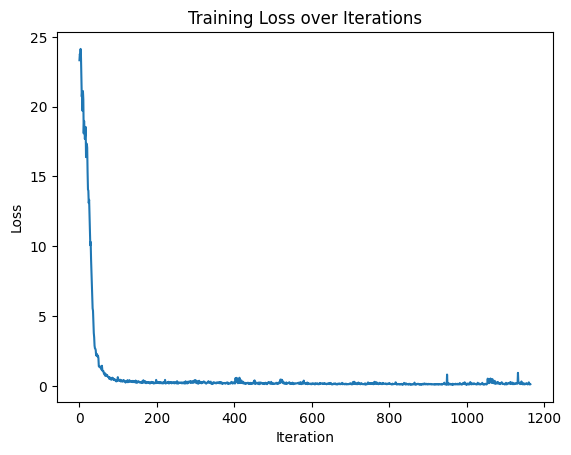

In [5]:
put_product = PutProductMultipleAssets()
trainer_product = SobolevTrainer(model_config, market_params, put_product, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)
trainer_product.train(batch_size=500, epochs=10000, tol=1e-6)
trainer_product.plot_losses()

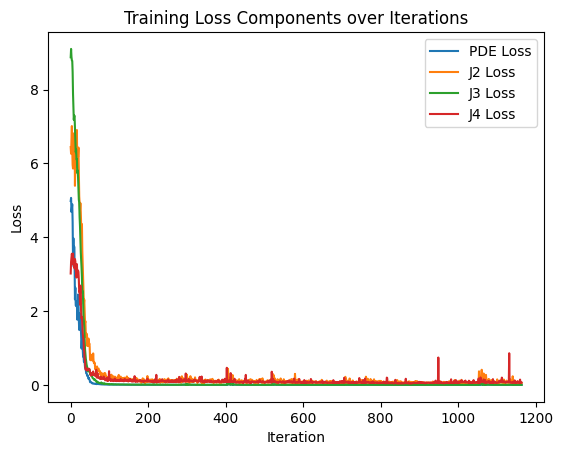

In [6]:
trainer_product.plot_losses_detailed()

### Compare with 1D case

In [7]:
r_prime = n_assets * r + np.sum(np.tril(sigma, k=-1))
sigma_prime = np.sqrt(np.sum(sigma))

market_params_1d = MarketParams(
    n_assets=1,
    S0=S0**n_assets,
    r=r_prime,
    sigma=sigma_prime,
    K=K,
    T=T,
    S_min=S_min**n_assets,
    S_max=S_max**n_assets
)
put_1d = Put()

bt_1d = BinomialTree(market_params_1d, n_steps=200)

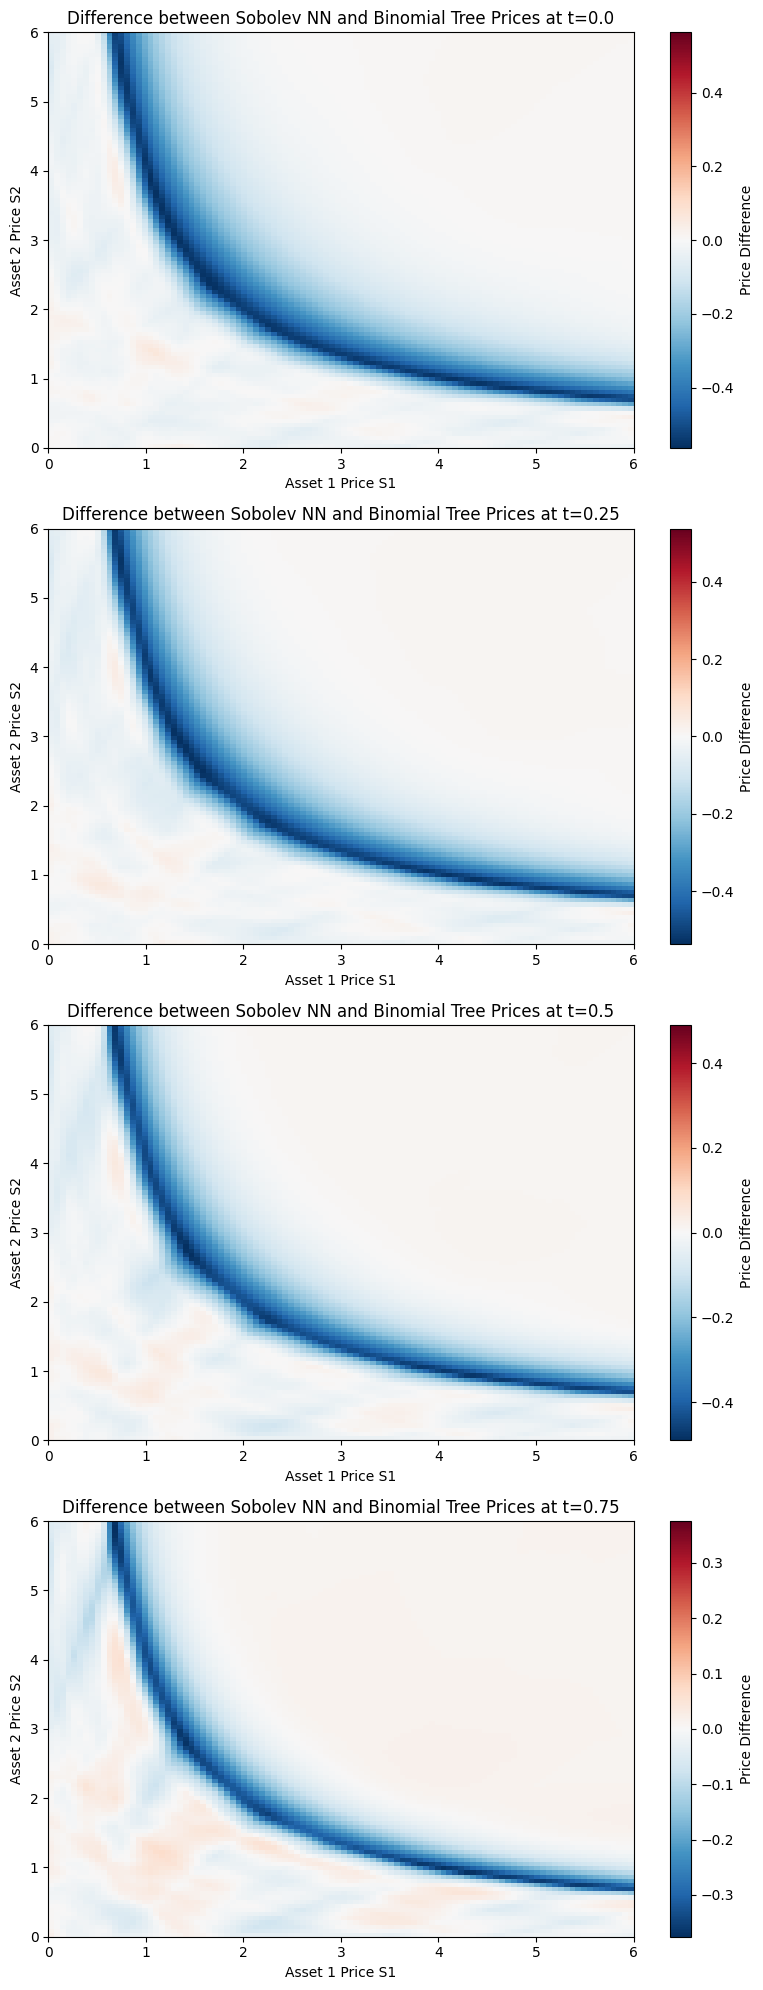

In [8]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 6.0, resolution)
S2 = np.linspace(0.0, 6.0, resolution)

ts = [0.0, 0.25, 0.5, 0.75]

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    prices_2d = trainer_product.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
    prices_1d = bt_1d.predict(t, (S1_grid * S2_grid).flatten()).reshape(S1_grid.shape)

    diff = prices_2d - prices_1d

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(diff).max()
    vmin = -vmax
    im = plt.imshow(diff, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price Difference')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'Difference between Sobolev NN and Binomial Tree Prices at t={t}')
plt.tight_layout()
plt.show()